In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!cp -r /content/drive/MyDrive/PlantVillage /content/

In [ ]:
import os
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()
dataset_path = "/content/PlantVillage"

print("Classes:", len(os.listdir(dataset_path)))
print(os.listdir(dataset_path))

Classes: 16
['Tomato_Leaf_Mold', 'Tomato__Tomato_mosaic_virus', 'Pepper__bell___healthy', 'Potato___healthy', 'Potato___Early_blight', 'Tomato_Late_blight', 'Tomato_Bacterial_spot', 'Tomato_healthy', 'Tomato_Early_blight', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Spider_mites_Two_spotted_spider_mite', '.DS_Store', 'Potato___Late_blight', 'Tomato__Target_Spot', 'Pepper__bell___Bacterial_spot', 'Tomato_Septoria_leaf_spot']


/tmp/ipykernel_1489/2633360090.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/PlantVillage"

classes = [d for d in os.listdir(dataset_path)
           if os.path.isdir(os.path.join(dataset_path, d))]

print("Number of classes:", len(classes))
print(classes)

Number of classes: 15
['Potato___healthy', 'Tomato_Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Tomato_mosaic_virus', 'Tomato_Leaf_Mold', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Tomato_Septoria_leaf_spot', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Potato___Early_blight', 'Tomato_healthy', 'Pepper__bell___Bacterial_spot']


In [ ]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="/content/PlantVillage",
    transform=transform
)

print("Total Images:", len(dataset))

Total Images: 20654


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="/content/PlantVillage",
    transform=transform
)

train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 14457
Validation: 3098
Test: 3099


In [ ]:
from torch.utils.data import DataLoader

batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

In [ ]:
import time

start = time.time()

images, labels = next(iter(train_loader))

print("Data Loading Time:", time.time() - start)

start = time.time()

images = images.to(device, non_blocking=True)

print("GPU Transfer Time:", time.time() - start)

Data Loading Time: 0.18663859367370605
GPU Transfer Time: 0.0005638599395751953


In [ ]:
images, labels = next(iter(train_loader))

print("Image Batch Shape:", images.shape)
print("Label Batch Shape:", labels.shape)

# 32 images per batch
# 3 color channels (RGB)
# 224×224 image size
# 32 labels corresponding to the 32 images

Image Batch Shape: torch.Size([8, 3, 224, 224])
Label Batch Shape: torch.Size([8])


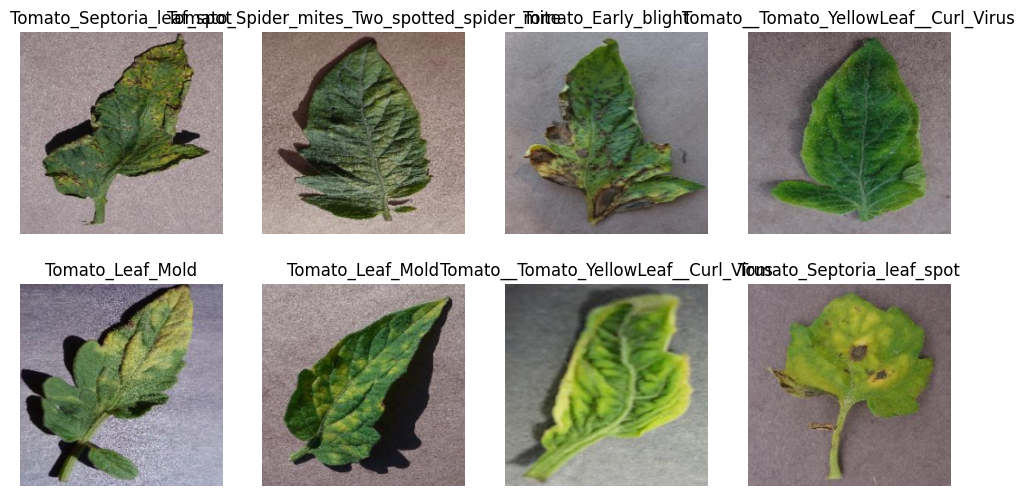

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12,6))

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1,2,0)
    ax.imshow(img)
    ax.set_title(dataset.classes[labels[i]])
    ax.axis('off')

plt.show()

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomCrop((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
import torch
import torch.nn as nn

class CustomCNN(nn.Module):

    def __init__(self):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

    def forward(self, x):
        return self.features(x)

In [ ]:
cnn = CustomCNN()

sample_batch, _ = next(iter(train_loader))

output = cnn(sample_batch)

print(output.shape)

torch.Size([8, 256, 28, 28])


In [ ]:
import torch
import torch.nn as nn

class DiseaseSeverityAttention(nn.Module):

    def __init__(self, channels):
        super(DiseaseSeverityAttention, self).__init__()

        self.severity = nn.Sequential(
            nn.Conv2d(
                channels,
                1,
                kernel_size=1
            ),
            nn.Sigmoid()
        )

    def forward(self, x):

        severity_map = self.severity(x)

        out = x * severity_map

        return out

In [ ]:
dsa = DiseaseSeverityAttention(256)

sample_batch, _ = next(iter(train_loader))

cnn_features = cnn(sample_batch)

output = dsa(cnn_features)

print("CNN Features :", cnn_features.shape)
print("DSA Output   :", output.shape)

CNN Features : torch.Size([8, 256, 28, 28])
DSA Output   : torch.Size([8, 256, 28, 28])


In [ ]:
import torch
import torch.nn as nn

class ChannelAttention(nn.Module):

    def __init__(self, channels, reduction=16):
        super(ChannelAttention, self).__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(channels,
                      channels // reduction,
                      kernel_size=1,
                      bias=False),

            nn.ReLU(),

            nn.Conv2d(channels // reduction,
                      channels,
                      kernel_size=1,
                      bias=False),

            nn.Sigmoid()
        )

    def forward(self, x):

        attention = self.fc(
            self.avg_pool(x)
        )

        return x * attention

In [ ]:
ca = ChannelAttention(256)

output = ca(cnn_features)

print(output.shape)

torch.Size([8, 256, 28, 28])


In [ ]:
import torch
import torch.nn as nn

class SpatialAttention(nn.Module):

    def __init__(self):
        super(SpatialAttention, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(
                2,
                1,
                kernel_size=7,
                padding=3,
                bias=False
            ),
            nn.Sigmoid()
        )

    def forward(self, x):

        avg_pool = torch.mean(
            x,
            dim=1,
            keepdim=True
        )

        max_pool, _ = torch.max(
            x,
            dim=1,
            keepdim=True
        )

        pooled = torch.cat(
            [avg_pool, max_pool],
            dim=1
        )

        attention = self.conv(pooled)

        return x * attention

In [ ]:
sa = SpatialAttention()

output = sa(cnn_features)

print(output.shape)

torch.Size([8, 256, 28, 28])


In [ ]:
import torch
import torch.nn as nn

class DSCBAM(nn.Module):

    def __init__(self, channels):
        super(DSCBAM, self).__init__()

        self.channel_attention = ChannelAttention(channels)

        self.spatial_attention = SpatialAttention()

        self.disease_severity_attention = DiseaseSeverityAttention(channels)

    def forward(self, x):

        x = self.channel_attention(x)

        x = self.spatial_attention(x)

        x = self.disease_severity_attention(x)

        return x

In [ ]:
dscbam = DSCBAM(256)

output = dscbam(cnn_features)

print(output.shape)

torch.Size([8, 256, 28, 28])


In [ ]:
sample_batch, _ = next(iter(train_loader))

cnn_features = cnn(sample_batch)

dscbam_features = dscbam(cnn_features)

print("CNN Output Shape:", cnn_features.shape)
print("DS-CBAM Output Shape:", dscbam_features.shape)

CNN Output Shape: torch.Size([8, 256, 28, 28])
DS-CBAM Output Shape: torch.Size([8, 256, 28, 28])


In [ ]:
# import torch
# import torch.nn as nn

# class DiseaseAwarePatchProjection(nn.Module):

#     def __init__(self):
#         super().__init__()

#         self.projection = nn.Conv2d(
#             in_channels=256,
#             out_channels=768,
#             kernel_size=1
#         )

#     def forward(self, x):

#         x = self.projection(x)

#         return x

In [ ]:
# projection = DiseaseAwarePatchProjection()

# projected_features = projection(
#     dscbam_features
# )

# print(projected_features.shape)

In [ ]:
# print(projected_features.shape)

In [ ]:
# class TokenGenerator(nn.Module):

#     def __init__(self):
#         super().__init__()

#     def forward(self, x):

#         B, C, H, W = x.shape

#         x = x.flatten(2)

#         x = x.transpose(1, 2)

#         return x


# #         Input Image
# #       ↓
# # Custom CNN
# #       ↓
# # DS-CBAM
# #       ↓
# # Global Average Pooling
# #       ↓
# # Feature Vector (256)
# #       ↓

# # Pretrained ViT
# # (Input Image Again)
# #       ↓
# # ViT Feature Vector (768)

# #       ↓
# # Feature Fusion

# #       ↓
# # Feature Enhancement Layer

# #       ↓
# # Classifier


# # This is called a Dual-Branch Hybrid CNN-ViT Architecture.

# # Advantages:

# # ✅ Easier implementation

# # ✅ Uses pretrained ViT correctly

# # ✅ Keeps your DS-CBAM novelty

# # ✅ Very common in published papers

# # ✅ Higher chance of training successfully

In [ ]:
# token_generator = TokenGenerator()

# tokens = token_generator(
#     projected_features
# )

# print(tokens.shape)


# #                 Input Image
# #                      │
# #         ┌────────────┴────────────┐
# #         │                         │
# #         ▼                         ▼

# #  Custom CNN                 Pretrained ViT
# #         │                         │
# #         ▼                         ▼

# #    DS-CBAM                 ViT Feature Vector
# #         │                         │
# #         ▼                         ▼

# #  CNN Feature Vector      ViT Feature Vector
# #         │                         │
# #         └────────────┬────────────┘
# #                      │
# #                      ▼

# #            Feature Fusion Layer
# #                      │
# #                      ▼

# #         Feature Enhancement Layer
# #                      │
# #                      ▼

# #               Softmax Classifier
# #                      │
# #                      ▼

# #          Plant Disease Prediction

In [ ]:
import torch
import torch.nn as nn

class CNNFeatureExtractor(nn.Module):

    def __init__(self):
        super().__init__()

        self.pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):

        x = self.pool(x)

        x = x.view(x.size(0), -1)

        return x

In [ ]:
cnn_feature_extractor = CNNFeatureExtractor()

cnn_vector = cnn_feature_extractor(
    dscbam_features
)

print(cnn_vector.shape)

torch.Size([8, 256])


In [ ]:
from torchvision.models import vit_b_16
from torchvision.models import ViT_B_16_Weights

weights = ViT_B_16_Weights.DEFAULT

vit = vit_b_16(weights=weights)

In [ ]:
vit.heads = nn.Identity()

In [ ]:
# Freeze entire ViT first
for param in vit.parameters():
    param.requires_grad = False

# Unfreeze last 2 transformer blocks
for param in vit.encoder.layers[-2:].parameters():
    param.requires_grad = True

# Keep layer norm trainable
for param in vit.encoder.ln.parameters():
    param.requires_grad = True

In [ ]:
trainable = sum(
    p.numel() for p in vit.parameters()
    if p.requires_grad
)

total = sum(
    p.numel() for p in vit.parameters()
)

print(f"Trainable: {trainable:,}")
print(f"Total: {total:,}")

In [ ]:
sample_batch, _ = next(iter(train_loader))

vit_features = vit(sample_batch)

print(vit_features.shape)

In [ ]:
import torch

fused_features = torch.cat(
    [cnn_vector, vit_features],
    dim=1
)

print(fused_features.shape)

In [ ]:
class FeatureEnhancement(nn.Module):

    def __init__(self):
        super().__init__()

        self.layer = nn.Sequential(

            nn.Linear(1024, 512),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(512, 256),

            nn.GELU()
        )

    def forward(self, x):

        return self.layer(x)

In [ ]:
feature_enhancement = FeatureEnhancement()

enhanced_features = feature_enhancement(
    fused_features
)

print(enhanced_features.shape)

In [ ]:
class Classifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.classifier = nn.Sequential(

            nn.Linear(256, 128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, 15)
        )

    def forward(self, x):

        return self.classifier(x)

In [ ]:
classifier = Classifier()

predictions = classifier(
    enhanced_features
)

print(predictions.shape)

In [ ]:
import torch
import torch.nn as nn

class HybridPlantDiseaseModel(nn.Module):

    def __init__(self):

        super().__init__()

        # Branch 1
        self.cnn = CustomCNN()

        self.dscbam = DSCBAM(256)

        self.cnn_feature_extractor = CNNFeatureExtractor()

        # Branch 2
        self.vit = vit

        # Fusion + Classification
        self.feature_enhancement = FeatureEnhancement()

        self.classifier = Classifier()

    def forward(self, x):

        # CNN Branch
        cnn_features = self.cnn(x)

        dscbam_features = self.dscbam(cnn_features)

        cnn_vector = self.cnn_feature_extractor(
            dscbam_features
        )

        # ViT Branch
        vit_vector = self.vit(x)

        # Fusion
        fused_features = torch.cat(
            [cnn_vector, vit_vector],
            dim=1
        )

        enhanced_features = self.feature_enhancement(
            fused_features
        )

        output = self.classifier(
            enhanced_features
        )

        return output

In [ ]:
model = HybridPlantDiseaseModel()

print(model)

In [ ]:
sample_batch, _ = next(iter(train_loader))

sample_batch = sample_batch[:8]

output = model(sample_batch)

print(output.shape)

In [ ]:
import torch
print(torch.cuda.is_available())

In [ ]:

import torch
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)
model = model.to(device)
print(device)


In [ ]:

import torch.nn as nn
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)


In [ ]:
import os
import torch
checkpoint_path = (
    "/content/drive/MyDrive/"
    "latest_checkpoint.pth"
)
start_epoch = 0
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path
    )
    model.load_state_dict(
        checkpoint['model_state_dict']
    )
    optimizer.load_state_dict(
        checkpoint['optimizer_state_dict']
    )
    start_epoch = (
        checkpoint['epoch'] + 1
    )
    print(
        f"Resuming from epoch "
        f"{start_epoch}"
    )
else:
    print(
        "Starting fresh training"
    )


In [ ]:
def train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(
            outputs,
            labels
        )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(
            outputs,
            1
        )
        total += labels.size(0)
        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    epoch_acc = (
        100 * correct / total
    )
    return epoch_loss, epoch_acc


In [ ]:
def validate(
    model,
    val_loader,
    criterion,
    device
):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with autocast():

              outputs = model(images)

              loss = criterion(
                  outputs,
                  labels
              )
            running_loss += loss.item()
            _, predicted = torch.max(
                outputs,
                1
            )
            total += labels.size(0)
            correct += (
                predicted == labels
            ).sum().item()
    val_loss = (
        running_loss /
        len(val_loader)
    )
    val_acc = (
        100 * correct / total
    )
    return val_loss, val_acc


In [ ]:
best_val_acc = 0

In [ ]:
# Training Loop with Real-Time Progress, ETA, Checkpoint Saving, and Best Model Saving

from tqdm import tqdm
import time
import torch

num_epochs = 30

best_val_acc = 0

total_train_images = len(train_dataset)

for epoch in range(start_epoch, num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    epoch_start_time = time.time()

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{num_epochs}",
        leave=True
    )

    for images, labels in progress_bar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        current_acc = 100 * correct / total

        elapsed_time = time.time() - epoch_start_time

        avg_time_per_image = elapsed_time / total

        remaining_images = total_train_images - total

        eta_seconds = remaining_images * avg_time_per_image

        progress_bar.set_postfix({
            "Loss": f"{loss.item():.4f}",
            "Acc": f"{current_acc:.2f}%",
            "Images": f"{total}/{total_train_images}",
            "ETA(min)": f"{eta_seconds/60:.1f}"
        })

    train_loss = running_loss / len(train_loader)

    train_acc = 100 * correct / total

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    epoch_time = time.time() - epoch_start_time

    print("\n")

    print(f"Epoch {epoch+1}/{num_epochs}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Train Accuracy: {train_acc:.2f}%")

    print(f"Validation Loss: {val_loss:.4f}")

    print(f"Validation Accuracy: {val_acc:.2f}%")

    print(f"Epoch Time: {epoch_time/60:.2f} min")

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }

    torch.save(
        checkpoint,
        "/content/drive/MyDrive/latest_checkpoint.pth"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/best_ds_cbam_model.pth"
        )

        print("✅ Best model saved!")

    print(
        f"Checkpoint Saved (Epoch {epoch+1})"
    )

    print("-" * 70)

print("\n🎉 Training Completed Successfully!")


In [ ]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
    print(torch.cuda.memory_allocated() / 1024**2, "MB")

In [ ]:
print(next(model.parameters()).device)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!mkdir "/content/drive/MyDrive/Plant-Disease-Detection"

In [3]:
!mv "/content/drive/MyDrive/Colab Notebooks/PlantDiseaseDetection.ipynb" "/content/drive/MyDrive/Plant-Disease-Detection/"

In [4]:
%cd "/content/drive/MyDrive/Plant-Disease-Detection"

/content/drive/MyDrive/Plant-Disease-Detection


In [5]:
!ls

PlantDiseaseDetection.ipynb


In [6]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/Plant-Disease-Detection/.git/


In [ ]:
!git config --global user.name "AshirwadKumar950"
!git config --global user.email "YOUR_EMAIL@example.com"